In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# In this version of the code, I will adapt the code slightly to be more aligned with the format of the FPAA, replacing voltage in for a gain term, replacing the individual components with cutoff frequencies, ensuring the filters are initialised such that the high pass band sits below the low pass band, and attempting to normalise gradient updates across parameters.

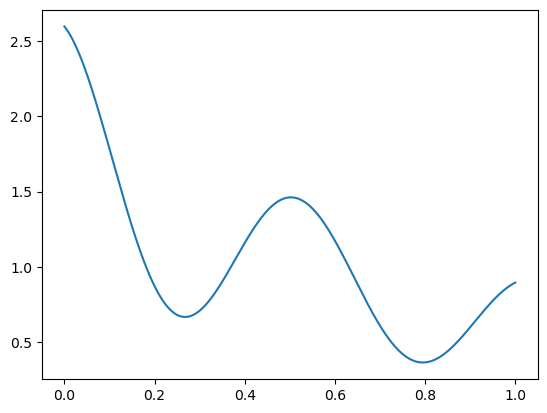

In [2]:
# Define the function to be fitted
def f(s):
    return 0.25*(torch.exp(1/(0.5*s+0.5))*torch.cos(5*s)*torch.cos(7*s)+3)

out = torch.zeros((1000))
s_in = torch.linspace(0, 1, 1000)
for i in range(1000):
    out[i] = f(s_in[i])
    
plt.figure()
plt.plot(s_in, out)
plt.show()

In [3]:
# Define a single KAN node to fit and see if it can fit the arbitrary function above
class KAN_node(nn.Module):
    def __init__(self, Nfilters):
        super().__init__()
        self.Nfilters = Nfilters
        self.filter_params = 4*(torch.rand((Nfilters, 3))-0.5).float()
        self.filter_params.requires_grad=True
        self.optim = torch.optim.Adam(params={self.filter_params}, lr=1e-3)
        self.lossfn = nn.MSELoss()
        
    # Torch definition of filter equations, where the parameters are bounded in [0,2]
    def band_pass(self, Xin):
        # Bound params
        params = self.filter_params.sigmoid()
        # Convert inputs to frequency space (exponentially varied across 1kHz-10 kHz)
        freq = 10**(2+3*Xin)
        freq = torch.tile(freq, (len(params), 1)).T
        # For 'sensible' initialisation, we'd like parameters that make sense for gain, f_low, and f_high:
        # Set gain between +/- 5x
        gain = 10*(params[:, 0]-0.5)
        # Set RC from sensible cutoff frequencies (f_c = 1/(2*pi*RC))
        fc_low = 10+(10**(6*params[:, 1]))
        fc_high = 10+(10**(6*params[:, 2]))
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        # Calculate steady-state response from filter equations
        Hout = gain[:]*torch.abs((2j*torch.pi*freq*RC_low[:]/(1+2j*torch.pi*freq*RC_low[:]))*(1/(1+2j*torch.pi*freq*RC_high[:])))
        return Hout.sum(dim=1)
    
    def forward(self, Xin):
        # Pass through filter bank
        out = self.band_pass(Xin)
        return out
    
    def train(self, Xin, Yin):
        self.optim.zero_grad()
        pred = self.forward(Xin)
        loss = self.lossfn(pred, Yin)
        loss.backward()
        self.optim.step()
        return(loss.item())

23.468584060668945
1.0188345186179504e-05
2.548783868405735e-06
1.9300646272313315e-06
2.2420124423661036e-06
2.18462741941039e-06
1.7648020502747386e-06
1.8604764591145795e-06
1.83526196906314e-06
1.8599238273964147e-06


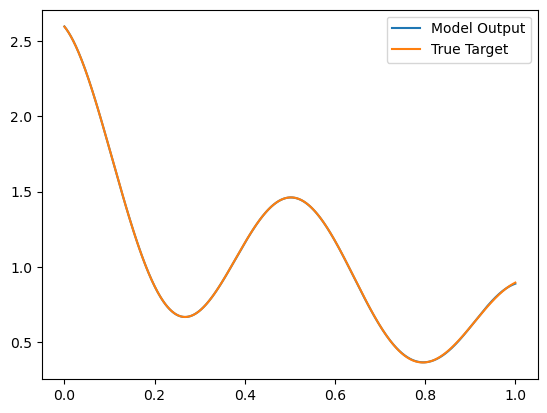

In [4]:
# Create a node
model = KAN_node(8)
# Train the node
for i in range(100000):
    Xs = torch.rand(1000)
    Ys = f(Xs)
    loss = model.train(Xs, Ys)
    if i%10000 == 0:
        print(loss)
Xs = torch.linspace(0, 1, 1000)
Ys = model.forward(Xs)
Y_True = f(Xs)

fig, ax = plt.subplots()

Xs = torch.linspace(0, 1, 1000)
Ys = model.forward(Xs)
Y_True = f(Xs)
line1, = ax.plot(Xs.cpu().detach().numpy().flatten(), Ys.cpu().detach().numpy().flatten(), label='Model Output')
line2, = ax.plot(Xs.cpu().detach().numpy().flatten(), Y_True.cpu().detach().numpy().flatten(), label='True Target')
plt.legend()
plt.show()


# The current version of the model works for a single node. It now needs to be generalised to handle networks of arbitrary sizes and shapes.

In [5]:
# Redefine instead as a network of KAN nodes
class PhyKAN(nn.Module):
    def __init__(self, KANshape, filters_per_unit):
        super().__init__()
        # Find number of layers
        self.Nlayers = len(KANshape)-1
        self.KANshape = KANshape
        # Create parameters for each layer
        self.filter_params = []
        for i in range(self.Nlayers):
            layer_params = 4*(torch.rand((KANshape[i], KANshape[i+1], filters_per_unit, 3))-0.5)
            layer_params.requires_grad=True
            self.filter_params.append(layer_params)
        self.optim = torch.optim.Adam(params=self.filter_params, lr=1e-3)
        self.lossfn = nn.MSELoss()
        
    # Redefined for torch & assuming trainable parameters
    def band_pass(self, Xin, params):
        # Bound parameters
        params=params.sigmoid()
        # Normalise input of 0-1 to frequencies of 100 Hz-100 kHz
        freq = 10**(2+3*Xin)
        freq = torch.tile(freq, (len(params), 1)).T
        # For 'sensible' initialisation, we'd like parameters that make sense for gain, f_low, and f_high:
        # Set gain between +/- 5X
        gain = 10*(params[:, 0]-0.5)
        # Set cutoff frequencies between 10 Hz and 1 MHz
        fc_low = 10+(10**(6*params[:, 1]))
        fc_high = 10+(10**(6*params[:, 2]))
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        Hout = gain[:]*torch.abs((2j*torch.pi*freq*RC_low[:]/(1+2j*torch.pi*freq*RC_low[:]))*(1/(1+2j*torch.pi*freq*RC_high[:])))
        return Hout.sum(dim=1)
    
    def forward(self, Xin):
        batch_size = len(Xin)
        # Initialise inputs to and outputs from each layer
        inputs = []
        outputs = []
        for i in range(self.Nlayers):
            inputs.append(torch.zeros((batch_size, self.KANshape[i])))
            outputs.append(torch.zeros((batch_size, self.KANshape[i+1])))
        inputs[0][:, :] = Xin
        # Pass through model
        for layer in range(self.Nlayers):
            for inp in range(self.KANshape[layer]):
                for node in range(self.KANshape[layer+1]):
                    outputs[layer][:, node] += self.band_pass(inputs[layer][:, inp], self.filter_params[layer][inp, node, :])      
            if layer < self.Nlayers-1:
                inputs[layer+1][:, :] = outputs[layer][:, :]
        return outputs[-1]
    
    def train(self, Xin, Yin):
        self.optim.zero_grad()
        pred = self.forward(Xin)
        loss = self.lossfn(pred, Yin)
        loss.backward()
        self.optim.step()
        return(loss.item())

In [6]:
# Now for a 2D function instead:
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)

In [7]:
model = PhyKAN([2, 1, 1], 8)

for i in range(100000):
    Xs = torch.rand(1000, 2)
    Ys = f(2*(Xs-0.5))
    loss = model.train(Xs, Ys)
    if i%10000 == 0:
        print(loss)


4.98970890045166
0.003028959734365344
0.0005005552084185183
0.0001871574786491692
0.0001466693647671491
0.00012010934733552858
5.96164827584289e-05
4.950052607455291e-05
6.694687908748165e-05
4.4013191654812545e-05


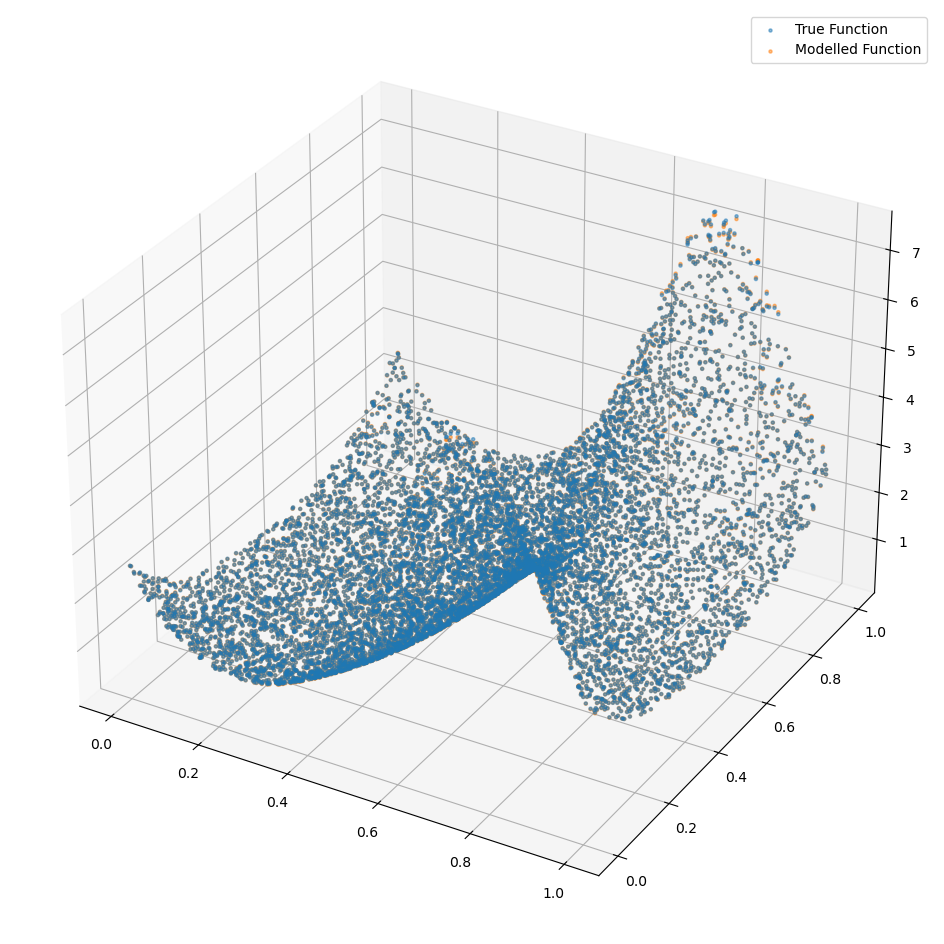

In [8]:
# Visualise the results in 3D:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')

xs = torch.rand(10000, 2)
y_true = f(2*(xs-0.5))
y_pred = model.forward(xs)

xs = xs.numpy()
y_true = y_true.numpy()
y_pred = y_pred.cpu().detach().numpy()

ax.scatter(xs[:, 0], xs[:, 1], y_true, label='True Function', alpha=0.5, s=5)
ax.scatter(xs[:, 0], xs[:, 1], y_pred, label='Modelled Function', alpha=0.5, s=5)
plt.legend()
plt.show()

2
torch.Size([2, 1, 8, 3])
torch.Size([1, 1, 8, 3])
tensor([[ 1.2878, -0.4831,  1.9273],
        [-1.1448,  0.0372, -0.4469],
        [-2.2863,  0.2129, -1.4979],
        [ 0.2593, -1.6324,  1.2094],
        [-1.8343,  1.5273, -1.2403],
        [ 0.9364, -0.9403, -1.0615],
        [-0.8438, -0.4863,  1.8629],
        [ 0.2043,  0.5768,  6.4355]], grad_fn=<SelectBackward0>)


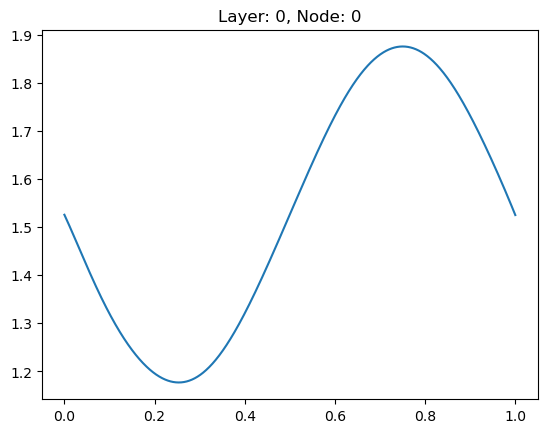

tensor([[ 0.8445,  1.8758, -1.4221],
        [ 0.2485, -0.6690, -1.1504],
        [ 1.7691,  1.8715, -1.2339],
        [ 0.2525, -0.6742, -1.9532],
        [-0.4899,  0.8061,  2.2230],
        [ 0.6772, -0.2777, -1.4458],
        [ 0.1291,  0.4777,  0.4287],
        [-0.6575, -1.2390,  0.6002]], grad_fn=<SelectBackward0>)


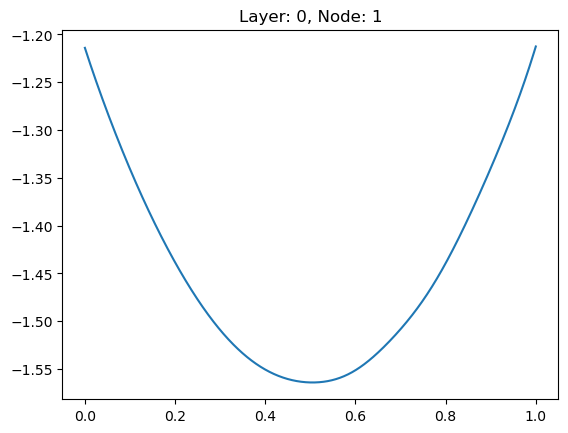

tensor([[-5.5997e-01, -6.0009e-01, -7.5841e-02],
        [ 3.1554e+00, -1.1996e+00,  8.1343e+00],
        [-1.1616e+00, -1.9422e+00, -7.5471e-01],
        [-4.8212e-01, -1.1977e+00,  5.4164e-01],
        [ 8.2277e-01, -9.5916e-02, -2.9103e+00],
        [ 1.4236e+00, -1.5191e+00, -3.5658e+00],
        [ 9.2913e+00,  6.9589e-01,  8.1062e+00],
        [ 3.4168e-03,  2.6888e+00, -1.5081e+00]], grad_fn=<SelectBackward0>)


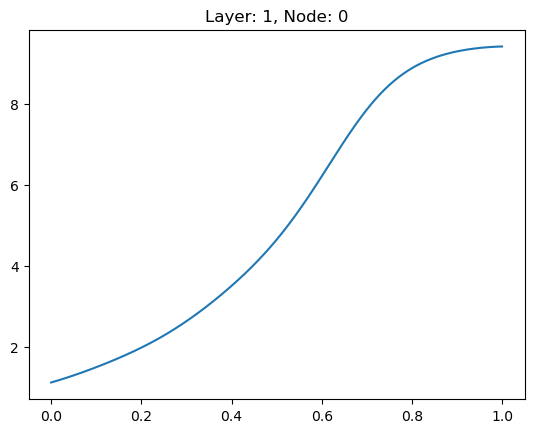

In [9]:
xin  = torch.linspace(0, 1, 1000)
filter_params = model.filter_params
print(len(filter_params))
print(filter_params[0].shape)
print(filter_params[1].shape)
for l, layer in enumerate(filter_params):
    for n, node in enumerate(layer):
        params = node[0]
        print(params)
        yf = model.band_pass(xin, params)
        plt.figure()
        plt.title('Layer: '+str(l)+', Node: '+str(n))
        plt.plot(xin.cpu().detach().numpy(), yf.cpu().detach().numpy())
        plt.show()